<a href="https://colab.research.google.com/github/harirkp006/MLOPS-TRAINING/blob/main/factory_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LINEAR REGRESSION




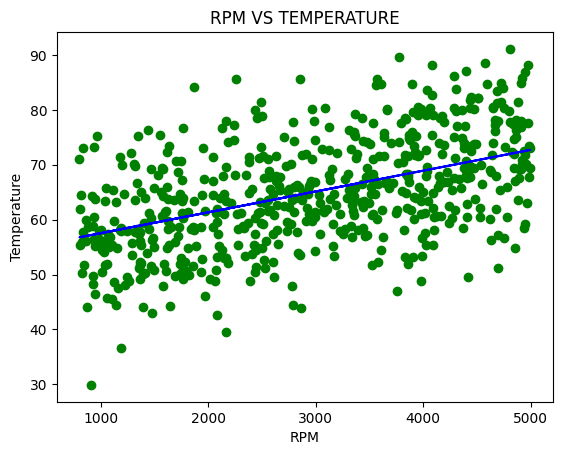

MSE  =>  71.67543021367283
R2  =>  0.27380323465589584
[54.05353682]


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


data=pd.read_csv("/content/factory_machinery_data.csv")
df=pd.DataFrame(data)

X=df[["RPM"]]
Y=df["Temperature"]

#train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42
    )
model = LinearRegression()
model.fit(X_train,Y_train)

prediction=model.predict(X_test)
plt.scatter(X_test,Y_test,color="green")
plt.plot(X_test,prediction,color="blue")
plt.ylabel("Temperature")
plt.xlabel("RPM")
plt.title("RPM VS TEMPERATURE")
plt.show()

#mean square error
MSE=mean_squared_error( Y_test,prediction)
print("MSE  => ",MSE)

#r2 value
r2 = r2_score(Y_test,prediction)
print("R2  => ",r2)

print(model.predict(pd.DataFrame([[80]], columns=["RPM"])))

# MULTI LINEAR REGRESSION

In [102]:
print(df.head())
modedummy=pd.get_dummies(df["Machine_Mode"],prefix="Machine_Mode").astype(int)
lvldummy=pd.get_dummies(df["Maintenance_Level"],prefix="Maintenance_Level").astype(int)
merge=pd.concat([df,modedummy,lvldummy],axis="columns")
merge=merge.drop(["Maintenance_Level","Machine_Mode","Shift_Type","Temperature"],axis="columns")
x = merge[["RPM","Vibration","Pressure","Humidity","Voltage","Current","Load","Operating_Hours", "Defective", "Machine_Mode_Eco","Machine_Mode_High-Speed","Machine_Mode_Standard","Maintenance_Level_Average","Maintenance_Level_Good","Maintenance_Level_Poor"]]
y=df["Temperature"]

#train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model1=LinearRegression()
model1.fit(x_train,y_train)
prediction1=model1.predict(x_test)

#mean square error
MSE=mean_squared_error( y_test,prediction1)
print("MSE  => ",MSE)
#r2 value
r2 = r2_score(y_test,prediction1)
print("R2  => ",r2)


    RPM  Vibration  Pressure  Humidity  Voltage  Current   Load  \
0  1660       5.17     88.80     66.87   240.90    42.59  51.93   
1  4572       0.61     32.04     83.55   216.75    45.21  31.48   
2  3892       4.68    113.85     34.72   242.87    42.05  72.09   
3  1266       4.54     38.12     49.85   240.77     9.64  60.90   
4  4244       4.53     82.28     44.90   233.87    15.24  16.97   

   Operating_Hours Machine_Mode Maintenance_Level Shift_Type  Temperature  \
0              937   High-Speed           Average    Morning        71.40   
1             9329     Standard              Poor    Evening        67.07   
2             5946   High-Speed           Average    Evening        84.69   
3             8563     Standard              Poor      Night        63.83   
4             2469          Eco           Average    Morning        60.22   

   Defective  
0          1  
1          1  
2          1  
3          1  
4          1  
MSE  =>  5.328991082328771
R2  =>  0.9460080

# SAVE USING PICKLE AND JOBLIB

In [104]:
import pickle
from joblib import dump,load

#joblib
dump(model,"modelfile.joblib")
m1=load("modelfile.joblib")

#pickle
with open("modelpkl","wb") as f:
  pickle.dump(model,f)
with open("modelpkl","rb") as f:
  m2=pickle.load(f)
m2.predict(pd.DataFrame([[85]],columns=["RPM"]))

array([54.07250547])